Diamonds Price Dataset

Import libraries 

pandas is used for datamanipulation 

Numpy is used for mathematical calculation

matplotlib is used for visulalization

seaborn is used for advance statistical visulalizations

LabelEncoder is used for Convert categorical values into numbers

train_test_split is used for Split dataset into training and testing sets.

metricsis used for Measure model performance.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load the dataset

In [2]:
df = pd.read_csv("diamonds.csv")

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Check rows, columns, datatype, and missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [4]:
df.shape

(53940, 10)

In [5]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

Filter the dataset and group the data to understand patterns.

Filtering

In [6]:

expensive_diamonds = df[df["price"] > 10000]

expensive_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
21928,1.70,Ideal,J,VS2,60.5,58.0,10002,7.73,7.74,4.68
21929,1.03,Ideal,E,VVS2,60.6,59.0,10003,6.50,6.53,3.95
21930,1.23,Very Good,G,VVS2,60.6,55.0,10004,6.93,7.02,4.23
21931,1.25,Ideal,F,VS2,61.6,55.0,10006,6.93,6.96,4.28
21932,2.01,Very Good,I,SI2,61.4,63.0,10009,8.19,7.96,4.96


GroupBy

In [7]:

cut_price = df.groupby("cut")["price"].mean()
print(cut_price)

cut
Fair         4358.757764
Good         3928.864452
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Name: price, dtype: float64


Multiple GroupBy

In [8]:

color_price = df.groupby("color")["price"].mean()
print(color_price)

color
D    3169.954096
E    3076.752475
F    3724.886397
G    3999.135671
H    4486.669196
I    5091.874954
J    5323.818020
Name: price, dtype: float64


Check Missing Values

In [9]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicate values

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 146


Remove duplicates

In [11]:

df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (53794, 10)


In [12]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Statistical summary

In [13]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


EDA - Exploratory Data Analysis

Distribution of Diamond Price

Histogram

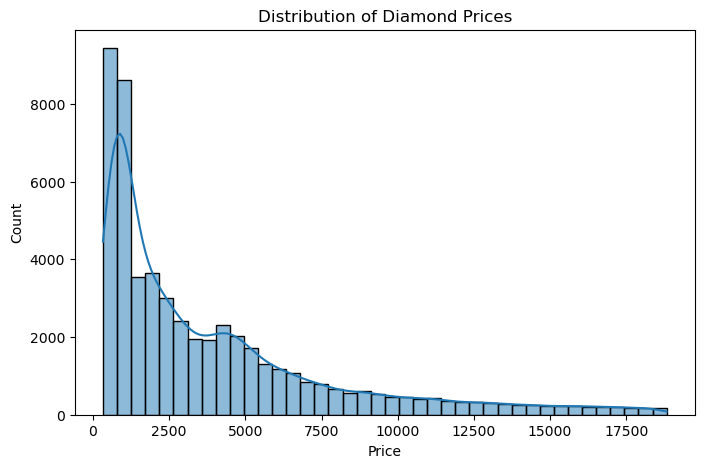

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Boxplot

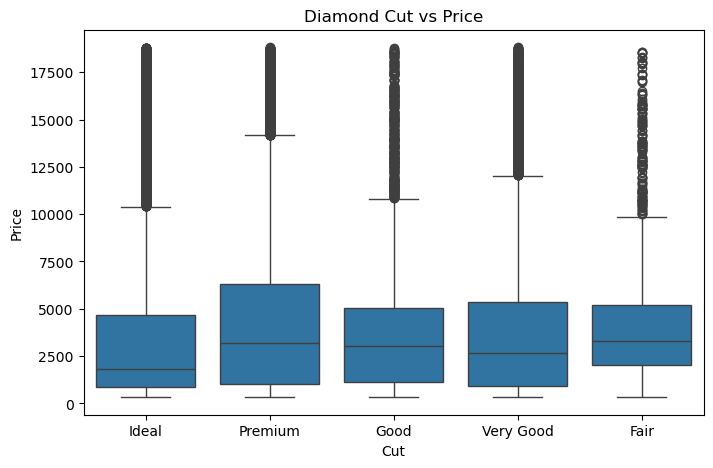

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cut", y="price", data=df)
plt.title("Diamond Cut vs Price")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.show()

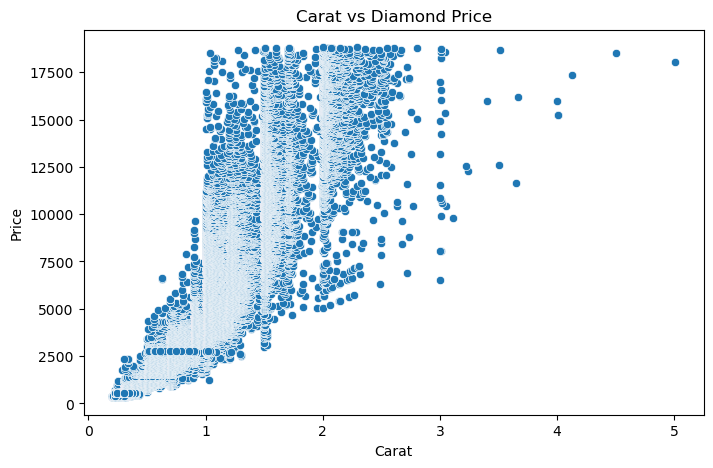

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="carat", y="price", data=df)
plt.title("Carat vs Diamond Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

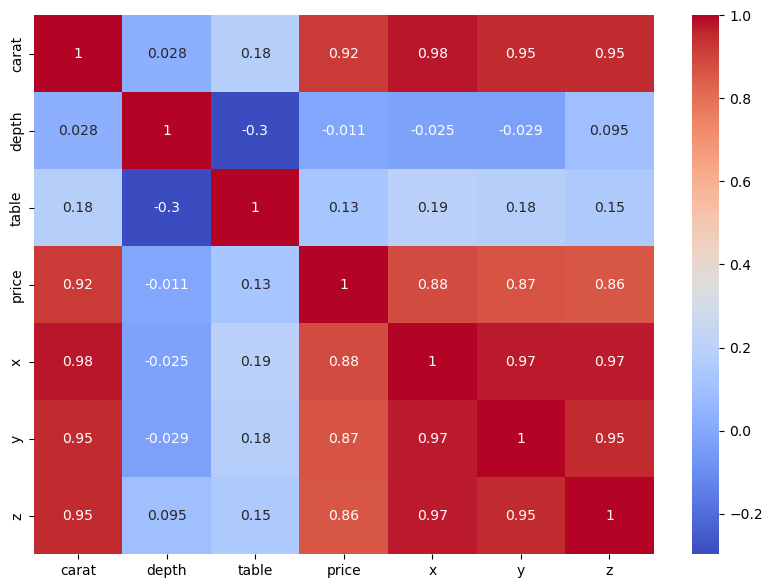

In [17]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

Encoding

Machine Learning models cannot understand text values directly, so convert them into numbers.

In [18]:
encoder = LabelEncoder()

df["cut"] = encoder.fit_transform(df["cut"])

df["color"] = encoder.fit_transform(df["color"])

df["clarity"] = encoder.fit_transform(df["clarity"])

In [19]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


Imbalance Data

 Check Data Distribution (Regression)

Regression datasets do not use SMOTE. Instead, check the distribution of the target variable.

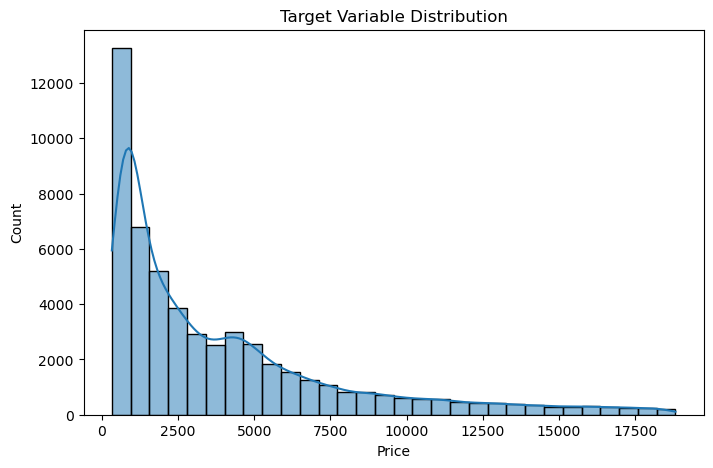

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Target Variable Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

 Split Features and Target

In [21]:
X = df.drop("carat", axis=1)

y = df["price"]

Split Dataset into Training and Testing

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature scaling

In [23]:
from sklearn.model_selection import train_test_split


X = df.drop("carat", axis=1)

y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (43035, 9)
Testing Data: (10759, 9)


Train Linear Regression Model

In [24]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict Diamond Prices

In [25]:
y_pred = lr.predict(X_test)

Evaluate Linear Regression Model




In [26]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2.088751288815305e-12
MSE : 6.606593933097393e-24
RMSE: 2.570329537840896e-12
R2 Score: 1.0


Compare Actual and Predicted Prices

In [27]:
results = pd.DataFrame({
    "Actual Price": y_test,

    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
43657,1435,1435.0
4274,3584,3584.0
47412,1851,1851.0
44437,1590,1590.0
13975,5690,5690.0
11387,596,596.0
40261,492,492.0
49095,2063,2063.0
37116,970,970.0
10485,4796,4796.0
